In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Task A

In [7]:
L = 6 #length of the chain
V = -1
t_start = 0
t_end = 20
#h_bar = 1.05457182e-34
h_bar = 1
epsilon1 = 2
c0 = [1,0,0,0,0,0]
t=np.linspace(t_start,t_end,1000)
H1 = np.array([
    [epsilon1, V,  0,  0,  0,  0],
    [V,  0, V,  0,  0,  0],
    [0,  V,  0, V,  0,  0],
    [0,  0, V,  0, V,  0],
    [0,  0,  0, V, 0, V],
    [0,  0,  0,  0, V, 0]
])

E_lambda, eigenvectors = np.linalg.eigh(H1)



def cn_lambdat(t,m):
 def cm():
    k = []

    for lam in range(L):
        b = np.vdot(eigenvectors[:, lam], c0)
        k.append(b)

    return k
 
 y = []
 for i in range(len(t)):    
     a = np.exp((-1j*E_lambda*t[i])/h_bar) *eigenvectors[m-1, :] *cm()
     y.append(np.sum(a))
     
 return  np.abs(np.array(y))**2

#print(eigenvectors[:,0])
print(cn_lambdat(t,1))

[1.         0.99959932 0.99839872 0.99640253 0.99361795 0.99005497
 0.98572641 0.98064778 0.97483723 0.96831549 0.96110574 0.95323352
 0.94472658 0.9356148  0.92593001 0.91570584 0.90497759 0.89378206
 0.88215735 0.87014273 0.85777843 0.84510545 0.83216543 0.81900038
 0.80565256 0.79216427 0.77857766 0.76493456 0.75127628 0.73764345
 0.72407587 0.71061231 0.69729035 0.68414627 0.6712149  0.65852944
 0.6461214  0.63402046 0.62225435 0.61084879 0.59982741 0.58921165
 0.57902075 0.56927167 0.55997906 0.55115527 0.54281031 0.53495189
 0.52758541 0.52071397 0.51433847 0.50845761 0.50306796 0.49816404
 0.4937384  0.4897817  0.48628284 0.48322899 0.48060578 0.47839739
 0.47658666 0.47515521 0.47408362 0.47335152 0.47293772 0.47282039
 0.47297716 0.47338527 0.47402172 0.47486337 0.47588712 0.47706998
 0.47838926 0.47982263 0.48134828 0.48294499 0.48459227 0.48627042
 0.48796065 0.48964514 0.49130711 0.49293091 0.49450204 0.49600722
 0.49743443 0.49877292 0.50001325 0.5011473  0.50216826 0.5030

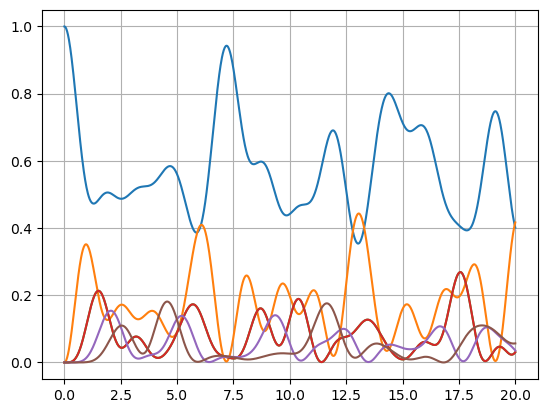

In [8]:
fig, ax = plt.subplots()
 
plt.plot(t,cn_lambdat(t,1))
plt.plot(t,cn_lambdat(t,2))
plt.plot(t,cn_lambdat(t,3))
plt.plot(t,cn_lambdat(t,3))
plt.plot(t,cn_lambdat(t,4))
plt.plot(t,cn_lambdat(t,5))
plt.grid()

# Task B

In [5]:
# Define values
L = 6
U_1 = 0
U_n = 15
V = -1
eps_1 = -15
eps_n = 0

In [6]:
# Create matrix
H = np.zeros((L**2, L**2))
# TODO: diagonal elements
H += np.diag(np.ones(L**2-1) * V, 1) # add the V elements directly offset from the diagonal
H += np.diag(np.ones(L**2-1) * V, -1) # " "
H[L * np.arange(1, L), L * np.arange(1, L) - 1] = 0 # get rid of the ones that aren't actually next to each other
H[L * np.arange(1, L) - 1, L * np.arange(1, L)] = 0 # " "
H += np.diag(np.ones(L**2-L) * V, L) # add the V elements far offset from the diagonal
H += np.diag(np.ones(L**2-L) * V, -L) # " "
print(H)

[[ 0. -1.  0. ...  0.  0.  0.]
 [-1.  0. -1. ...  0.  0.  0.]
 [ 0. -1.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0. -1.  0.]
 [ 0.  0.  0. ... -1.  0. -1.]
 [ 0.  0.  0. ...  0. -1.  0.]]


In [77]:
#Implementation of the Eq27 for two particles:
eigenvalues , eigenvectors = np.linalg.eigh(H) #eigenvalues are the energy values and the eigenvectors contain the expansion coefficents
#print(eigenvectors_rearranged)
c0 = np.array([-15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
#print(np.shape(c0))
delta = 15




def cm(t):
    k = []

    for l in range(36):
        b = np.vdot(eigenvectors[:, l], c0)
        k.append(b)
        #print(k)

    return k


def cn_lambdat2(t,n,m): #t is the time, n is the index for the basis vector(basis function) in the Hilbertspace(L²) that contains particle 1 and m is the index of the basis vector that contains particle 2
 
 
 y = []
 for i in range(len(t)):    
     a = np.exp((-1j*eigenvalues*t[i])/h_bar) *eigenvectors[(n-1)*6 + (m-1), :] *cm(t[i])
     y.append(np.sum(a))
     
 return  np.abs(np.array(y))**2

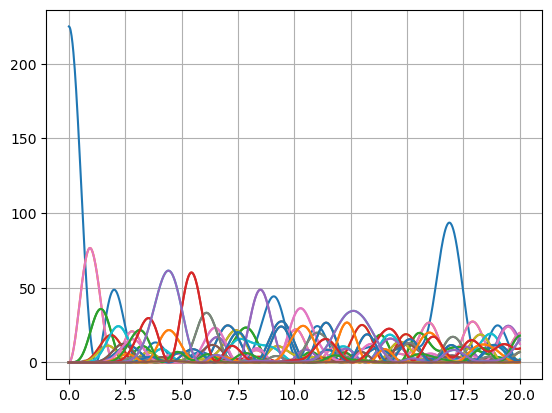

In [78]:
fig, ax = plt.subplots()
for n in range(L):
    for m in range(L):
        plt.plot(t,cn_lambdat2(t,n+1,m+1))

plt.grid()

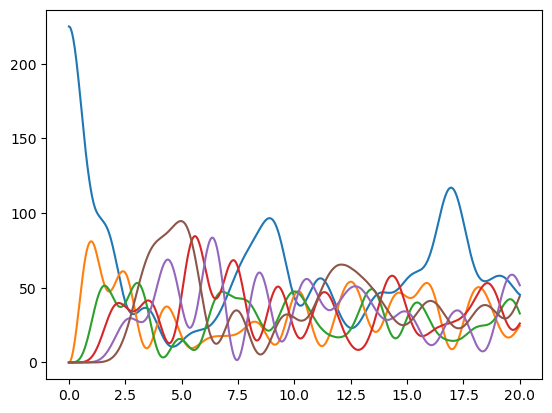

In [79]:
for n in range(L):
    p_up = np.zeros(1000)   
    for m in range(L):
        p_up += cn_lambdat2(t,n+1,m+1)
    plt.plot(t,p_up)         